# PV Forecasting (Restart from Original)
This notebook is a clean, consistent rebuild of the original with the **minimum set of fixes** needed to stop the “always sunny / too high bell curve” behavior.

Key fixes:
- **Proper forecasting dataset**: model sees **past PV + past weather** (plant state) and **future weather** (forecast drivers).
- **No leakage**: scalers fit only on training split (and per fold if you use CV).
- **Seq2seq model**: predicts a value **per horizon step**, not a whole day from a single timestep.
- **Train on log1p(PV)** to reduce peak overshoot; convert back for plotting.


In [1]:

# --- Settings ---
RUN_TRAINING = True

LOOKBACK = 168   # past hours (7 days)
HORIZON  = 24    # forecast hours
TEST_HOURS = 744 # holdout length in HOURS (not sequences)

LOCAL_TZ = None  # e.g. "Europe/Berlin" if your PV is local-time aligned. Leave None to use UTC.

SEED = 42


In [2]:

import os, glob, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_, spectral_norm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Load & merge data

In [3]:

pv_data = pd.read_csv("../data/PV_2022_hourly.csv")
weather_data = pd.read_csv("../data/Weather_clean_NEMS.csv")

df_pv = pv_data.copy()
df_weather = weather_data.copy()

df_pv["TimestampInUtc"] = pd.to_datetime(df_pv["TimestampInUtc"], utc=True, errors="coerce")
df_weather["timestamp"] = pd.to_datetime(df_weather["timestamp"], utc=True, errors="coerce")

df_merged = df_pv.rename(columns={"TimestampInUtc":"ts"}).merge(
    df_weather.rename(columns={"timestamp":"ts"}),
    on="ts", how="inner"
).sort_values("ts").reset_index(drop=True)

# Optional: convert to local timezone BEFORE creating hour/month/day features
if LOCAL_TZ is not None:
    df_merged["ts_local"] = df_merged["ts"].dt.tz_convert(LOCAL_TZ)
else:
    df_merged["ts_local"] = df_merged["ts"]  # keep UTC

df_merged["hour"] = df_merged["ts_local"].dt.hour
df_merged["day_of_year"] = df_merged["ts_local"].dt.dayofyear
df_merged["month"] = df_merged["ts_local"].dt.month

df_merged["hour_sin"]  = np.sin(2*np.pi*df_merged["hour"]/24)
df_merged["hour_cos"]  = np.cos(2*np.pi*df_merged["hour"]/24)
df_merged["month_sin"] = np.sin(2*np.pi*df_merged["month"]/12)
df_merged["month_cos"] = np.cos(2*np.pi*df_merged["month"]/12)
df_merged["doy_sin"]   = np.sin(2*np.pi*df_merged["day_of_year"]/365.0)
df_merged["doy_cos"]   = np.cos(2*np.pi*df_merged["day_of_year"]/365.0)

# Clean PV (no negatives)
df_merged["pv"] = df_merged["pv"].clip(lower=0)

df_merged.head()


,ts,pv,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total,ts_local,hour,day_of_year,month,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
0,2022-01-01 00:00:00+00:00,0.0,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0,2022-01-01 00:00:00+00:00,0,1,1,0.000000,1.000000,0.5,0.866025,0.017213,0.999852
1,2022-01-01 01:00:00+00:00,0.0,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0,2022-01-01 01:00:00+00:00,1,1,1,0.258819,0.965926,0.5,0.866025,0.017213,0.999852
2,2022-01-01 02:00:00+00:00,0.0,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0,2022-01-01 02:00:00+00:00,2,1,1,0.500000,0.866025,0.5,0.866025,0.017213,0.999852
3,2022-01-01 03:00:00+00:00,0.0,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0,2022-01-01 03:00:00+00:00,3,1,1,0.707107,0.707107,0.5,0.866025,0.017213,0.999852
4,2022-01-01 04:00:00+00:00,0.0,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0,2022-01-01 04:00:00+00:00,4,1,1,0.866025,0.500000,0.5,0.866025,0.017213,0.999852


## Features
We keep the original weather + cyclic time features, and **add past PV** as an input (plant state). Future PV is unknown, so we provide a `pv_known` flag and set future pv input to 0.

Target is **log1p(pv)** to reduce overshoot.


In [4]:

TARGET_COL = "pv"
df_merged["y_log"] = np.log1p(df_merged[TARGET_COL].values.astype(np.float32))

CONTINUOUS_FEATURES = [
    "Temperature", "Sunshine Duration", "Shortwave Radiation",
    "Direct Shortwave Radiation", "Diffuse Shortwave Radiation",
    "Snowfall Amount", "Relative Humidity", "Cloud Cover Total"
]
# keep only those that exist (robust to column name changes)
CONTINUOUS_FEATURES = [c for c in CONTINUOUS_FEATURES if c in df_merged.columns]

CYCLIC_FEATURES = ["hour_sin","hour_cos","month_sin","month_cos","doy_sin","doy_cos"]

# Inputs we will build:
# - continuous weather (scaled)
# - cyclic time (not scaled)
# - pv_in (past pv; future pv_in=0)
# - pv_known flag (1 in history, 0 in future)


## Build forecasting tensors (history + future weather)
For each sample starting at time t:
- Input sequence length = LOOKBACK + HORIZON
  - first LOOKBACK steps: past weather/time + past pv
  - next HORIZON steps: future weather/time + pv_in=0 (unknown)
- Target = PV for next HORIZON hours (t .. t+HORIZON-1) in log space.


In [5]:

def build_forecast_tensors(df, lookback, horizon, continuous_cols, cyclic_cols, target_log_col="y_log"):
    Xc = df[continuous_cols].values.astype(np.float32)           # (N, C)
    Xcy = df[cyclic_cols].values.astype(np.float32)             # (N, K)
    pv = df["pv"].values.astype(np.float32)                     # (N,)
    ylog = df[target_log_col].values.astype(np.float32)         # (N,)

    N = len(df)
    seq_len = lookback + horizon
    X_list, Y_list = [], []

    # last start index so that we have lookback history and horizon future
    # Need history ending at t-1, and target from t..t+horizon-1
    for t in range(lookback, N - horizon):
        # history indices: t-lookback .. t-1 (length lookback)
        h_idx = slice(t - lookback, t)
        # future indices: t .. t+horizon-1 (length horizon)
        f_idx = slice(t, t + horizon)

        # Build per-step features for history and future
        # Weather/time available for both history and future
        hist_cont = Xc[h_idx]
        fut_cont  = Xc[f_idx]
        hist_cyc  = Xcy[h_idx]
        fut_cyc   = Xcy[f_idx]

        # PV input: known in history, unknown in future
        pv_hist = pv[h_idx].reshape(-1, 1)
        pv_fut  = np.zeros((horizon, 1), dtype=np.float32)

        known_hist = np.ones((lookback, 1), dtype=np.float32)
        known_fut  = np.zeros((horizon, 1), dtype=np.float32)

        X_hist = np.concatenate([hist_cont, hist_cyc, pv_hist, known_hist], axis=1)
        X_fut  = np.concatenate([fut_cont,  fut_cyc,  pv_fut,  known_fut],  axis=1)

        X_seq = np.concatenate([X_hist, X_fut], axis=0)  # (lookback+horizon, F)

        # Target: next horizon PV in log space (t..t+horizon-1)
        Y = ylog[f_idx]  # (horizon,)

        X_list.append(X_seq)
        Y_list.append(Y)

    X = np.stack(X_list, axis=0)  # (S, T, F)
    Y = np.stack(Y_list, axis=0)  # (S, horizon)
    return X, Y

X_raw, Y_log = build_forecast_tensors(df_merged, LOOKBACK, HORIZON, CONTINUOUS_FEATURES, CYCLIC_FEATURES, "y_log")
print("X_raw:", X_raw.shape, "Y_log:", Y_log.shape)


X_raw: (8566, 192, 16) Y_log: (8566, 24)


## Train/holdout split
We split by **time**: the last `TEST_HOURS` hours become the holdout window.

Since each training sample needs LOOKBACK history and HORIZON future, we convert hours to sequences safely.


In [6]:

# Convert TEST_HOURS to approx sequences in X_raw space.
# Each sequence predicts a horizon starting at time t. The last sequence start corresponds to near the end of df.
# We'll take the last `TEST_HOURS` *starts* as test sequences (reasonable for day-ahead evaluation).
TEST_SIZE_SEQ = TEST_HOURS

X_train_raw = X_raw[:-TEST_SIZE_SEQ]
Y_train_log = Y_log[:-TEST_SIZE_SEQ]
X_test_raw  = X_raw[-TEST_SIZE_SEQ:]
Y_test_log  = Y_log[-TEST_SIZE_SEQ:]

print("Train:", X_train_raw.shape, Y_train_log.shape)
print("Test :", X_test_raw.shape,  Y_test_log.shape)


Train: (7822, 192, 16) (7822, 24)
Test : (744, 192, 16) (744, 24)


## Scaling (train-only)
Scale only continuous weather columns. Cyclic + pv_in + pv_known stay unscaled.


In [7]:

# feature layout: [cont(C), cyc(6), pv_in(1), pv_known(1)]
C = len(CONTINUOUS_FEATURES)
K = len(CYCLIC_FEATURES)
F_total = X_train_raw.shape[-1]
assert F_total == C + K + 2

scaler_X = StandardScaler()

def scale_X(train_X, test_X):
    tr = train_X.copy()
    te = test_X.copy()
    tr_cont = tr[:, :, :C].reshape(-1, C)
    te_cont = te[:, :, :C].reshape(-1, C)
    scaler_X.fit(tr_cont)
    tr[:, :, :C] = scaler_X.transform(tr_cont).reshape(tr.shape[0], tr.shape[1], C)
    te[:, :, :C] = scaler_X.transform(te_cont).reshape(te.shape[0], te.shape[1], C)
    return tr.astype(np.float32), te.astype(np.float32)

X_train, X_test = scale_X(X_train_raw, X_test_raw)


## Dataset / DataLoader

In [8]:

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train_log), batch_size=32, shuffle=True, num_workers=0)
test_loader  = DataLoader(SeqDataset(X_test,  Y_test_log),  batch_size=64, shuffle=False, num_workers=0)


## TCN seq2seq model (replicate padding)

In [9]:

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation

        self.pad1  = nn.ReplicationPad1d((pad, 0))
        self.conv1 = spectral_norm(nn.Conv1d(in_channels, out_channels, kernel_size,
                                             stride=1, padding=0, dilation=dilation))
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.pad2  = nn.ReplicationPad1d((pad, 0))
        self.conv2 = spectral_norm(nn.Conv1d(out_channels, out_channels, kernel_size,
                                             stride=1, padding=0, dilation=dilation))
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.down = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.out_relu = nn.ReLU()

    def forward(self, x):
        out = self.drop1(self.relu1(self.conv1(self.pad1(x))))
        out = self.drop2(self.relu2(self.conv2(self.pad2(out))))
        res = x if self.down is None else self.down(x)
        return self.out_relu(out + res)

class TCNForecaster(nn.Module):
    def __init__(self, input_size, num_channels=(64,64,64), kernel_size=3, dropout=0.1, horizon=24):
        super().__init__()
        layers = []
        for i, ch in enumerate(num_channels):
            in_ch = input_size if i == 0 else num_channels[i-1]
            dilation = 2**i
            layers.append(TemporalBlock(in_ch, ch, kernel_size, dilation, dropout))
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(num_channels[-1], 1)
        self.horizon = horizon

    def forward(self, x):
        # x: (B, T, F)
        x_ch = x.transpose(1, 2)         # (B, F, T)
        h = self.tcn(x_ch)               # (B, C, T)
        h = h.transpose(1, 2)            # (B, T, C)
        y = self.head(h).squeeze(-1)     # (B, T)

        # We only care about the last HORIZON steps (future window)
        y = y[:, -self.horizon:]         # (B, HORIZON)
        return y


## Train / eval (log space)

In [10]:

def train_one_epoch(model, loader, optimizer):
    model.train()
    total, n = 0.0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(Xb)

        loss = F.smooth_l1_loss(pred, yb)
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * Xb.size(0)
        n += Xb.size(0)
    return total / n

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total, n = 0.0, 0
    preds, trues = [], []
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)
        pred = model(Xb)
        loss = F.smooth_l1_loss(pred, yb)
        total += loss.item() * Xb.size(0)
        n += Xb.size(0)
        preds.append(pred.cpu().numpy())
        trues.append(yb.cpu().numpy())
    P = np.concatenate(preds, axis=0)
    Y = np.concatenate(trues, axis=0)
    return total / n, P, Y

def metrics_pv_units(P_log, Y_log):
    P = np.expm1(P_log.clip(min=0))  # log space can go slightly negative; clip for stability
    Y = np.expm1(Y_log.clip(min=0))
    mse = mean_squared_error(Y.reshape(-1), P.reshape(-1))
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(Y.reshape(-1), P.reshape(-1))
    return mse, rmse, mae


## Run training

In [11]:

EPOCHS = 1
LR = 1e-3

model = TCNForecaster(input_size=X_train.shape[-1], num_channels=(64,64,64,64), kernel_size=3, dropout=0.1, horizon=HORIZON).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_rmse = float("inf")
best_state = None

for epoch in range(1, EPOCHS+1):
    tr = train_one_epoch(model, train_loader, optimizer)
    va_loss, P_log, Y_log = eval_epoch(model, test_loader)
    mse, rmse, mae = metrics_pv_units(P_log, Y_log)

    if rmse < best_rmse:
        best_rmse = rmse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:03d} | train loss {tr:.5f} | test loss {va_loss:.5f} | PV RMSE {rmse:.3f} | PV MAE {mae:.3f}")

if best_state is not None:
    model.load_state_dict(best_state)


Epoch 001 | train loss 0.25241 | test loss 0.16404 | PV RMSE 9.004 | PV MAE 3.611


## Plot an example 24h forecast (holdout)

Per-day RMSE: mean 7.7101 median 7.262001 p90 14.76276731491089
Per-day MAE : mean 3.6108947 median 3.2506409 p90 6.7767249107360845


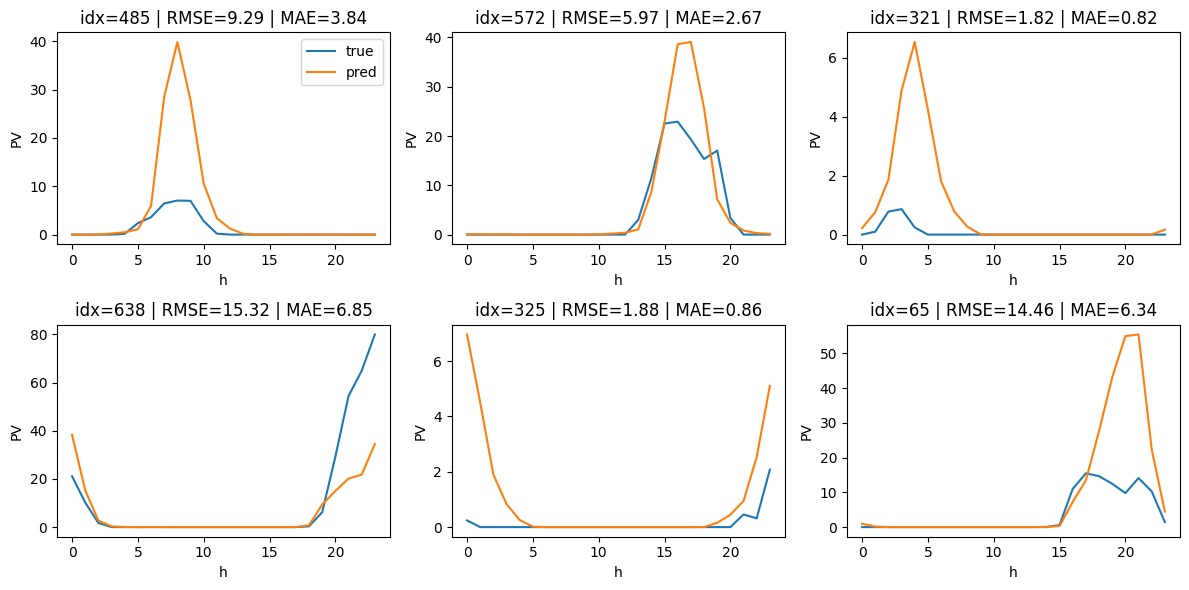

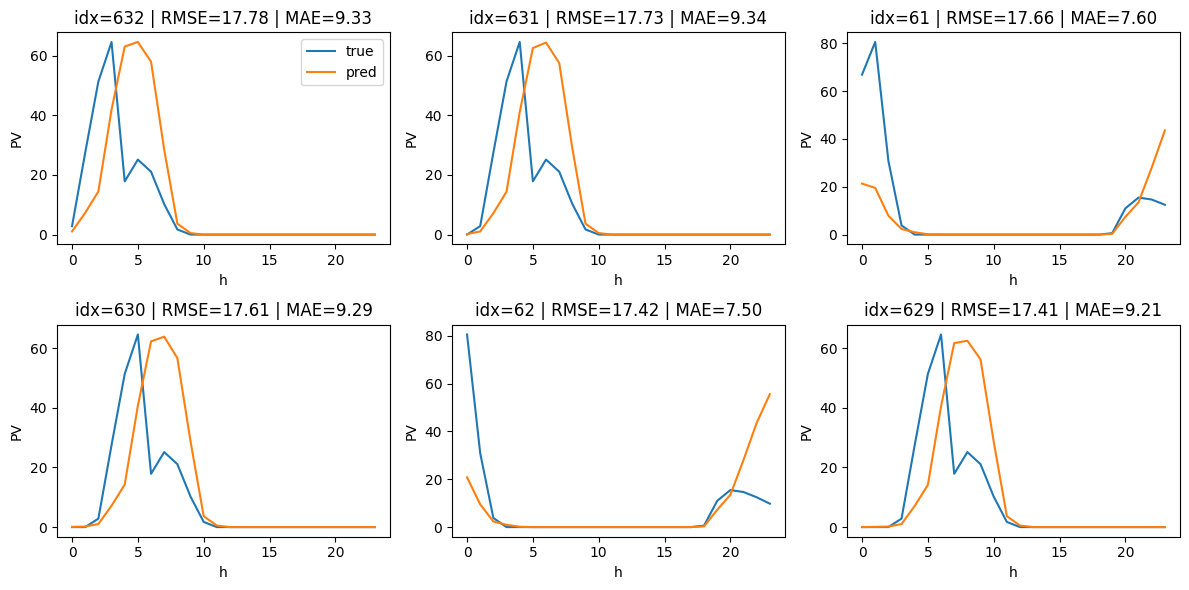

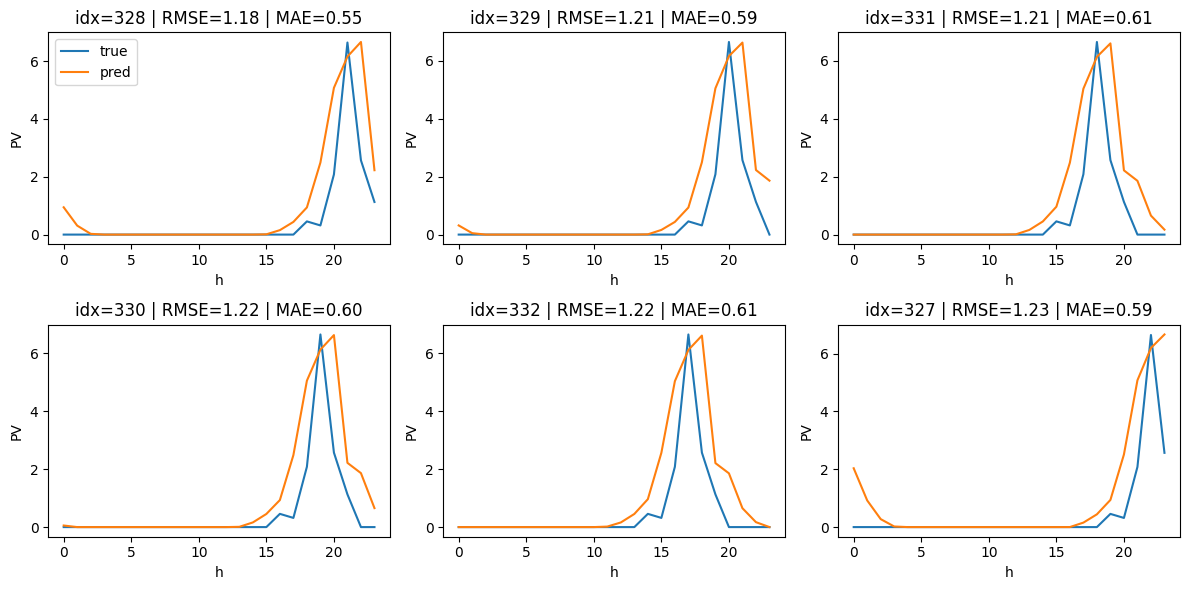

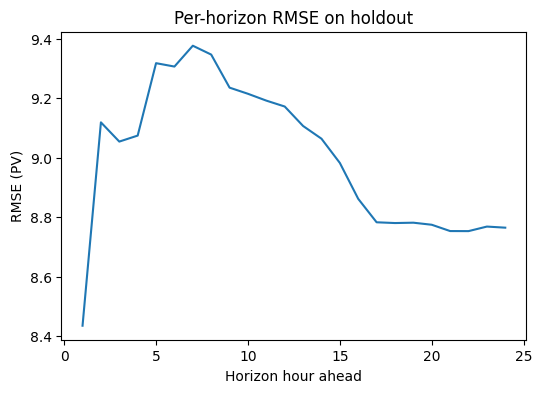

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- per-day metrics (in PV units) ---
def per_day_metrics(P, Y):
    """
    P, Y: (N, 24) in PV units
    returns arrays of shape (N,) for mse/rmse/mae per forecast window
    """
    err = P - Y
    mse = np.mean(err**2, axis=1)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(err), axis=1)
    return mse, rmse, mae

mse_d, rmse_d, mae_d = per_day_metrics(P, Y)

print("Per-day RMSE: mean", rmse_d.mean(), "median", np.median(rmse_d), "p90", np.quantile(rmse_d, 0.9))
print("Per-day MAE : mean", mae_d.mean(),  "median", np.median(mae_d),  "p90", np.quantile(mae_d, 0.9))


# --- plot K example days (choose mode: 'random', 'worst', 'best') ---
def plot_days(P, Y, K=9, mode="random", seed=42):
    N = len(P)
    if mode == "random":
        rng = np.random.default_rng(seed)
        idxs = rng.choice(N, size=min(K, N), replace=False)
    elif mode == "worst":
        idxs = np.argsort(rmse_d)[-min(K, N):][::-1]
    elif mode == "best":
        idxs = np.argsort(rmse_d)[:min(K, N)]
    else:
        raise ValueError("mode must be 'random', 'worst', or 'best'")

    # grid size
    cols = int(np.ceil(np.sqrt(len(idxs))))
    rows = int(np.ceil(len(idxs) / cols))

    plt.figure(figsize=(cols*4, rows*3))
    for i, idx in enumerate(idxs, 1):
        plt.subplot(rows, cols, i)
        plt.plot(Y[idx], label="true")
        plt.plot(P[idx], label="pred")
        plt.title(f"idx={idx} | RMSE={rmse_d[idx]:.2f} | MAE={mae_d[idx]:.2f}")
        plt.xlabel("h")
        plt.ylabel("PV")
        if i == 1:
            plt.legend()
    plt.tight_layout()
    plt.show()

# examples:
plot_days(P, Y, K=6, mode="random")
plot_days(P, Y, K=6, mode="worst")
plot_days(P, Y, K=6, mode="best")


# --- per-horizon metrics across ALL days (PV units) ---
def per_horizon_metrics(P, Y):
    err = P - Y
    mse = np.mean(err**2, axis=0)        # (24,)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(err), axis=0)
    return mse, rmse, mae

mse_h, rmse_h, mae_h = per_horizon_metrics(P, Y)

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, 25), rmse_h)
plt.xlabel("Horizon hour ahead")
plt.ylabel("RMSE (PV)")
plt.title("Per-horizon RMSE on holdout")
plt.show()